In [1]:
import math

In [2]:
def golden_section(f, a, b, eps=1e-6, max_iter=100):
   
    phi = (1 + 5**0.5) / 2   # 1.618...
    k1 = 1 - 1 / phi          # 0.382
    k2 = 1 / phi              # 0.618

    # Первые две внутренние точки
    x1 = a + k1 * (b - a)
    x2 = a + k2 * (b - a)

    f1 = f(x1)
    f2 = f(x2)
    func_calls = 2  # счётчик вызовов функции

    for iteration in range(max_iter):
        current_len = b - a        

        if current_len < eps:
            break        

        if f1 < f2:
            # Минимум слева → [a, x2]
            b = x2
            x2 = x1  # старая x1 → новая x2
            f2 = f1
            x1 = a + k1 * (b - a) # считаем только одну новую точку
            f1 = f(x1)
            func_calls += 1
        else:
            # Минимум справа → [x1, b]
            a = x1
            x1 = x2                    # старая x2 → новая x1
            f1 = f2
            x2 = a + k2 * (b - a)
            f2 = f(x2)   # считаем только одну новую точку
            func_calls += 1

    x_opt = (a + b) / 2
    f_opt = f(x_opt)
    func_calls += 1
    return x_opt, f_opt, iteration + 1, func_calls

def parabolic(f, a, b, eps=1e-6, max_iter=100):
    # находим третью точку
    c = (a + b) / 2  
    f_a, f_b, f_c = f(a), f(b), f(c)
    
    # проверяем, что функция в середине меньше, чем на концах
    if f_c > f_a or f_c > f_b:
        raise ValueError("середина отрезка не является самой низкой точкой")
    
    # x1=a, x2=c, x3=b
    x1, x2, x3 = a, c, b
    f1, f2, f3 = f_a, f_c, f_b
    func_calls = 3  # счётчик вызовов f

    #считаем вершину параболы  
    for iteration in range(max_iter):
      
        D1 = (f2 - f1) / (x2 - x1)
        D2 = (f3 - f2) / (x3 - x2)
        A = (D2 - D1) / (x3 - x1)

        if abs(A) < 1e-12:
            # возвращаем текущую лучшую точку
            return x2, f2, iteration + 1, False, func_calls
        
        # Вершина параболы 
        x_new = (x1 + x2) / 2 - D1 / (2 * A)
        f_new = f(x_new)
        func_calls += 1

        if abs(x_new - x2) < eps:
            return x_new, f_new, iteration + 1, True, func_calls

        points = [(x1, f1), (x2, f2), (x3, f3), (x_new, f_new)]
        points.sort(key=lambda p: p[0]) 

        worst = max(points, key=lambda point: point[1]) 
        points.remove(worst)

        x1, f1 = points[0]
        x2, f2 = points[1]
        x3, f3 = points[2]

    return x2, f2, max_iter, False, func_calls

def brent(f, a, b, eps=1e-3, max_iter=100):
    # a, b	границы текущего отрезка
    # x	лучшая точка (самое низкое f)
    # w	вторая по качеству точка
    # v	третья по качеству точка
    # u	новая точка-кандидат
    # d	шаг, сделанный в прошлый раз
    # e	шаг, сделанный перед d
    # c_gold = (3−√5)/2	константа золотого сечения ≈ 0.382

    c_gold = (3 - math.sqrt(5)) / 2 
    x = w = v = a + c_gold * (b - a)
    fx = fw = fv = f(x)
    d = 0
    e = 0
    func_calls = 1

    for iteration in range (max_iter):
        if (b - a) < eps:
            break

        u = None

        if e != 0 and v != w and w != x and v != x: #можно ли строить параболу?
            D1 = (fw - fx) / (w - x)
            D2 = (fv - fw) / (v - w)
            A = (D2 - D1) / (v - x)

            if abs(A) > 1e-12: # если парабола не вырождается в прямую, ищем вершину
                apex = (x + w) / 2 - D1 / (2 * A)
                if a < apex < b and abs(apex - x) < 0.5 * abs(e):
                    u = apex    #тогда вершина кандидат на новую лучшую точку

        if u is None: # если парабола не подошла или не получилась, пробуем золотое сечение
            if x < (a + b) / 2: #если в левой половине, шагаем вправо
                u = x + (b - x) * c_gold
            else: 
                u = x - (x - a) * c_gold

        e = d
        d = u - x   #величина текущего шага
        fu = f(u)
        func_calls += 1

        if fu <= fx:    #если новая точка лучше x
            if u >= x:
                a = x
            else:
                b = x
            v, fv = w, fw
            w, fw = x, fx
            x, fx = u, fu
        else:   #если хуже x
            if u >= x:
                b = u
            else:
                a = u
                
            #но если она улчше w или v
            if fu <= fw or w == x: 
                v, fv = w, fw
                w, fw = u, fu
            elif fu <= fv or v == x or v == w:
                v, fv = u, fu

    return x, fx, func_calls, iteration 

Вариации координатного спуска с различными методами для одномерного шага (золотое сечение, параболический, метод Брента)

In [3]:
def make_func_along_x(f, y_fixed):
    def g(x):
        return f(x, y_fixed)             
    return g

def make_func_along_y(f, x_fixed):
    def h(y):
        return f(x_fixed, y) 
    return h

In [4]:
def coordinate_descent_golden(f, bounds, eps=1e-3, max_iter=1000):
    
    # Вычисляем середину границ для каждой координаты
    x = (bounds[0][0] + bounds[0][1]) / 2
    y = (bounds[1][0] + bounds[1][1]) / 2

    converged = False 
    iteration_count = 0
    func_calls = 0  # счётчик вызовов f

    # Обёртка для подсчёта вызовов одномерной функции
    def counted_1d(g):
        def wrapper(x):
            nonlocal func_calls
            func_calls += 1
            return g(x)
        return wrapper

    for iteration in range(max_iter):
        x_old, y_old = x, y

        x_bounds, y_bounds = bounds[0], bounds[1]

        g_x = make_func_along_x(f, y) 
        x, _, _, _ = golden_section(counted_1d(g_x), x_bounds[0], x_bounds[1], eps)

        h_y = make_func_along_y(f, x)
        y, _, _, _ = golden_section(counted_1d(h_y), y_bounds[0], y_bounds[1], eps)

        iteration_count += 1

        if abs(x - x_old) < eps and abs(y - y_old) < eps:
            converged = True
            break  
            
    return x, y, converged, iteration_count, func_calls

In [5]:
def coordinate_descent_parabolic(f, bounds, eps=1e-3, max_iter=1000):
    
    # Вычисляем середину границ для каждой координаты
    x = (bounds[0][0] + bounds[0][1]) / 2
    y = (bounds[1][0] + bounds[1][1]) / 2

    converged = False 
    iteration_count = 0
    func_calls = 0  # счётчик вызовов f

    # Обёртка для подсчёта вызовов одномерной функции
    def counted_1d(g):
        def wrapper(x):
            nonlocal func_calls
            func_calls += 1
            return g(x)
        return wrapper

    for iteration in range(max_iter):
        x_old, y_old = x, y

        x_bounds, y_bounds = bounds[0], bounds[1]

        g_x = make_func_along_x(f, y) 
        x, _, _, _, _ = parabolic(counted_1d(g_x), x_bounds[0], x_bounds[1], eps)

        h_y = make_func_along_y(f, x)
        y, _, _, _, _ = parabolic(counted_1d(h_y), y_bounds[0], y_bounds[1], eps)

        iteration_count += 1

        if abs(x - x_old) < eps and abs(y - y_old) < eps:
            converged = True
            break  
            
    return x, y, converged, iteration_count, func_calls

In [6]:
def coordinate_descent_brent(f, bounds, eps=1e-3, max_iter=1000):
    
    # Вычисляем середину границ для каждой координаты
    x = (bounds[0][0] + bounds[0][1]) / 2
    y = (bounds[1][0] + bounds[1][1]) / 2

    converged = False 
    iteration_count = 0
    func_calls = 0  # счётчик вызовов f

    # Обёртка для подсчёта вызовов одномерной функции
    def counted_1d(g):
        def wrapper(x):
            nonlocal func_calls
            func_calls += 1
            return g(x)
        return wrapper

    for iteration in range(max_iter):
        x_old, y_old = x, y

        x_bounds, y_bounds = bounds[0], bounds[1]

        g_x = make_func_along_x(f, y) 
        x, _, _, _ = brent(counted_1d(g_x), x_bounds[0], x_bounds[1], eps)

        h_y = make_func_along_y(f, x)
        y, _, _, _ = brent(counted_1d(h_y), y_bounds[0], y_bounds[1], eps)

        iteration_count += 1

        if abs(x - x_old) < eps and abs(y - y_old) < eps:
            converged = True
            break  
            
    return x, y, converged, iteration_count, func_calls

## Тесты: верификация покоординатного спуска

Проверяем три варианта метода — `coordinate_descent_golden`, `coordinate_descent_parabolic`,
`coordinate_descent_brent` — на наборе из 16 тестов (для температурного поля добавлены два варианта области с седлом внутри):

* синтетические тесты (квадратичные, повёрнутая квадратичная, овражная функция Розенброка);
* параболоид: осевой и повёрнутый через аффинное преобразование `u = A @ (x, y) + b`;
* 8 задач с двумя параметрами из `Решение задач с двумя параметрами.ipynb` (задача 6 одномерная и здесь не участвует).

Для каждой функции эталонный минимум известен заранее (аналитически или численно). Спуск стартует
из центра прямоугольника поиска, `eps = 1e-3`. Допуск сверки: `ATOL_XY = 0.05` по координатам; значение функции — с относительным допуском
`ATOL_F = 1e-2` (доля от `|f|`, но не меньше 0.01).

Сначала идёт `assert`-блок (проверки обязаны пройти), затем сводка и таблица-сравнение всех трёх методов.


In [7]:
# ============================================================
# Функции для тестирования: эталонный минимум известен заранее
# ============================================================

# --- Синтетические тестовые функции ---
def f_quad_23(x, y):
    return (x - 2) ** 2 + (y - 3) ** 2

def f_quad_4m4(x, y):
    return (x - 4) ** 2 + (y + 4) ** 2

def f_rot(x, y):
    # повёрнутая квадратичная: (x + y - 1)^2 + (x - y)^2
    return (x + y - 1) ** 2 + (x - y) ** 2

def f_rosenbrock(x, y):
    # овражная функция Розенброка
    return (1 - x) ** 2 + 100 * (y - x ** 2) ** 2


# --- Параболоид: осевой и повёрнутый ---
def f_paraboloid(x, y):
    return x ** 2 + y ** 2

# Повёрнутый параболоид через аффинное преобразование u = A @ (x, y) + b, f = u1^2 + u2^2.
# A = [[2, 1], [-1, 1.5]],  b = [1, -2].
# Минимум там, где A @ (x, y) + b = 0  =>  (x, y) = (-0.875, 0.75).
def f_paraboloid_rot(x, y):
    u1 = 2.0 * x + 1.0 * y + 1.0
    u2 = -1.0 * x + 1.5 * y - 2.0
    return u1 ** 2 + u2 ** 2


# --- Задачи с двумя параметрами (см. «Решение задач с двумя параметрами.ipynb») ---
def f_1(y, z):
    return 32 / z + 64 / y + 2 * y * z

def f_2(a, b):
    return -(54 * a * b - a ** 2 * b - a * b ** 2)

POINTS = [(1, 2), (2, 2), (3, 4), (4, 5), (5, 6)]
def f_3(k, b):
    return sum((k * x + b - y) ** 2 for x, y in POINTS)

def f_4(x, y):
    return (math.sqrt(x ** 2 + y ** 2)
            + math.sqrt((x - 8) ** 2 + y ** 2)
            + math.sqrt((x - 4) ** 2 + (y - 6) ** 2))

def f_5(x, y):
    return -(40 * x + 50 * y - x ** 2 - y ** 2 - x * y)

def f_7(x1, x2):
    return (math.sqrt(4 + x1 ** 2) / 4
            + math.sqrt((x2 - x1) ** 2 + 9) / 2
            + math.sqrt((10 - x2) ** 2 + 4) / 3)

def f_8(y, z):
    return -(6 * y * z - 1.5 * y ** 2 * z - 2 * y * z ** 2)

def f_9(x, y):
    return x ** 3 + y ** 3 - 3 * x * y


# --- Набор тестов: (название, функция, прямоугольник, эталон (x, y), примечание) ---
R5 = [[-5.0, 5.0], [-5.0, 5.0]]
CASES = [
    ("quad (x-2)^2+(y-3)^2",   f_quad_23,        R5,                          (2.0, 3.0),              ""),
    ("quad (x-4)^2+(y+4)^2",   f_quad_4m4,       R5,                          (4.0, -4.0),             ""),
    ("повёрнутая quad",        f_rot,            R5,                          (0.5, 0.5),              ""),
    ("параболоид",             f_paraboloid,     R5,                          (0.0, 0.0),              ""),
    ("параболоид повёрнутый",  f_paraboloid_rot, R5,                          (-0.875, 0.75),          ""),
    ("Розенброк",              f_rosenbrock,     R5,                          (1.0, 1.0),              "овражная функция — ограничение метода"),
    ("1. Аквариум",            f_1,              [[0.0, 5.0], [0.0, 5.0]],    (4.0, 2.0),              ""),
    ("2. Посылка",             f_2,              [[0.0, 40.0], [0.0, 40.0]],  (18.0, 18.0),            ""),
    ("3. МНК",                 f_3,              [[-2.0, 3.0], [-2.0, 3.0]],  (1.1, 0.5),              ""),
    ("4. Склад",               f_4,              [[0.0, 8.0], [0.0, 6.0]],    (4.0, 4 / math.sqrt(3)), ""),
    ("5. Два товара",          f_5,              [[0.0, 30.0], [0.0, 30.0]],  (10.0, 20.0),            ""),
    ("7. Три слоя",            f_7,              [[0.0, 10.0], [0.0, 10.0]],  (6.3252, 7.9526),        "эталон численный"),
    ("8. Ящик",                f_8,              [[0.0, 2.5], [0.5, 1.5]],    (4 / 3, 1.0),            ""),
    ("9. Температура",         f_9,              [[0.5, 1.5], [0.5, 1.5]],    (1.0, 1.0),              "седло в (0; 0) вне прямоугольника"),
    ("9b. Температура (седло внутри)", f_9, [[-0.4, 2.0], [-0.4, 2.0]], (1.0, 1.0), "седло (0; 0) внутри; глобальный минимум области — (1; 1)"),
    ("9c. Температура (старт в седле)", f_9, [[-2.0, 2.0], [-2.0, 2.0]], (-2.0, -2.0), "старт в седле (0; 0); уходим в угол (-2; -2)"),
]


In [8]:
from IPython.display import Markdown, display

ATOL_XY = 0.05      # допуск по координатам
ATOL_F = 1e-2       # относительный допуск по значению функции (доля от |f|)

METHODS = [
    ("golden",    coordinate_descent_golden),
    ("parabolic", coordinate_descent_parabolic),
    ("brent",     coordinate_descent_brent),
]

records = []
for name, f, bounds, ref, note in CASES:
    for method, runner in METHODS:
        try:
            x, y, conv, it, calls = runner(f, bounds)
            err_xy = max(abs(x - ref[0]), abs(y - ref[1]))
            err_f = abs(f(x, y) - f(ref[0], ref[1]))
            f_ok = err_f < ATOL_F * max(1.0, abs(f(ref[0], ref[1])))
            status = "OK" if (err_xy < ATOL_XY and f_ok) else "не сошлось"
            records.append(dict(name=name, method=method, x=x, y=y, fv=f(x, y),
                                conv=conv, it=it, calls=calls, status=status, note=note))
        except Exception as exc:
            records.append(dict(name=name, method=method, x=None, y=None, fv=None,
                                conv=None, it=None, calls=None,
                                status=f"ограничение: {type(exc).__name__}", note=note))

# --- assert-блок: проверки, которые обязаны пройти ---
# 1) золотое сечение и Брент находят эталон во всех задачах, кроме овражной
for r in records:
    if r["note"].startswith("овражная"):
        continue
    if r["method"] in ("golden", "brent"):
        assert r["status"] == "OK", f"{r['method']} не сошёлся на '{r['name']}': {r['status']}"

# 2) parabolic применим не везде; отказ должен быть ожидаемым (ValueError /
#    ZeroDivisionError), а не произвольной ошибкой
ALLOWED_LIMITS = ("ограничение: ValueError", "ограничение: ZeroDivisionError")
for r in records:
    if r["method"] == "parabolic":
        assert (r["status"] in ("OK", "не сошлось")) or (r["status"] in ALLOWED_LIMITS), (
            f"parabolic: неожиданный статус на '{r['name']}': {r['status']}")

# 3) характеристика ограничения: на овражной функции метод рапортует converged=True,
#    хотя точка далека от истинного минимума
for r in records:
    if r["note"].startswith("овражная"):
        assert r["conv"] is True, f"на овражной ожидалось ложное converged=True ({r['method']})"

print("Assert-блок: все проверки пройдены.")

# --- сводка по методам ---
print()
for method, _ in METHODS:
    ok = sum(1 for r in records if r["method"] == method and r["status"] == "OK")
    bad = sum(1 for r in records if r["method"] == method and r["status"] == "не сошлось")
    lim = sum(1 for r in records if r["method"] == method and r["status"].startswith("ограничение"))
    print(f"{method:10s}: сошлось {ok:2d} | не сошлось {bad:2d} | ограничение метода {lim:2d}")

# --- таблица-сравнение ---
lines = [
    "| Функция | Метод | x | y | f(x, y) | Итераций | Вызовов | Статус | Примечание |",
    "|:---|:---|:---:|:---:|:---:|:---:|:---:|:---|:---|",
]
for r in records:
    if r["x"] is None:
        lines.append(
            f"| {r['name']} | {r['method']} | — | — | — | — | — | {r['status']} | {r['note']} |")
    else:
        lines.append(
            f"| {r['name']} | {r['method']} | {r['x']:+.4f} | {r['y']:+.4f} | {r['fv']:+.4f} "
            f"| {r['it']} | {r['calls']} | {r['status']} | {r['note']} |")
display(Markdown("\n".join(lines)))


Assert-блок: все проверки пройдены.

golden    : сошлось 15 | не сошлось  1 | ограничение метода  0
parabolic : сошлось 10 | не сошлось  1 | ограничение метода  5
brent     : сошлось 15 | не сошлось  1 | ограничение метода  0


| Функция | Метод | x | y | f(x, y) | Итераций | Вызовов | Статус | Примечание |
|:---|:---|:---:|:---:|:---:|:---:|:---:|:---|:---|
| quad (x-2)^2+(y-3)^2 | golden | +2.0000 | +2.9998 | +0.0000 | 2 | 92 | OK |  |
| quad (x-2)^2+(y-3)^2 | parabolic | — | — | — | — | — | ограничение: ValueError |  |
| quad (x-2)^2+(y-3)^2 | brent | +2.0000 | +3.0000 | +0.0000 | 2 | 31 | OK |  |
| quad (x-4)^2+(y+4)^2 | golden | +3.9999 | -3.9999 | +0.0000 | 2 | 92 | OK |  |
| quad (x-4)^2+(y+4)^2 | parabolic | — | — | — | — | — | ограничение: ValueError |  |
| quad (x-4)^2+(y+4)^2 | brent | +4.0000 | -4.0000 | +0.0000 | 2 | 47 | OK |  |
| повёрнутая quad | golden | +0.4998 | +0.4998 | +0.0000 | 2 | 92 | OK |  |
| повёрнутая quad | parabolic | +0.5000 | +0.5000 | +0.0000 | 2 | 20 | OK |  |
| повёрнутая quad | brent | +0.5000 | +0.5000 | +0.0000 | 2 | 50 | OK |  |
| параболоид | golden | -0.0001 | -0.0001 | +0.0000 | 1 | 46 | OK |  |
| параболоид | parabolic | +0.0000 | +0.0000 | +0.0000 | 1 | 8 | OK |  |
| параболоид | brent | +0.0000 | +0.0000 | +0.0000 | 1 | 22 | OK |  |
| параболоид повёрнутый | golden | -0.8750 | +0.7500 | +0.0000 | 4 | 184 | OK |  |
| параболоид повёрнутый | parabolic | -0.8750 | +0.7500 | +0.0000 | 4 | 40 | OK |  |
| параболоид повёрнутый | brent | -0.8750 | +0.7500 | +0.0000 | 4 | 66 | OK |  |
| Розенброк | golden | +0.7929 | +0.6286 | +0.0429 | 189 | 8694 | не сошлось | овражная функция — ограничение метода |
| Розенброк | parabolic | +0.0004 | +0.0000 | +0.9992 | 1 | 8 | не сошлось | овражная функция — ограничение метода |
| Розенброк | brent | +0.8337 | +0.6950 | +0.0277 | 247 | 6219 | не сошлось | овражная функция — ограничение метода |
| 1. Аквариум | golden | +3.9996 | +2.0003 | +48.0000 | 7 | 294 | OK |  |
| 1. Аквариум | parabolic | — | — | — | — | — | ограничение: ZeroDivisionError |  |
| 1. Аквариум | brent | +3.9999 | +2.0000 | +48.0000 | 7 | 153 | OK |  |
| 2. Посылка | golden | +17.9997 | +18.0001 | -5832.0000 | 7 | 364 | OK |  |
| 2. Посылка | parabolic | +17.9998 | +18.0001 | -5832.0000 | 7 | 70 | OK |  |
| 2. Посылка | brent | +17.9998 | +18.0001 | -5832.0000 | 7 | 185 | OK |  |
| 3. МНК | golden | +1.1002 | +0.4995 | +0.7000 | 2 | 84 | OK |  |
| 3. МНК | parabolic | +1.1000 | +0.5000 | +0.7000 | 2 | 18 | OK |  |
| 3. МНК | brent | +1.1000 | +0.5000 | +0.7000 | 2 | 43 | OK |  |
| 4. Склад | golden | +4.0003 | +2.3095 | +12.9282 | 2 | 88 | OK |  |
| 4. Склад | parabolic | +4.0000 | +2.3094 | +12.9282 | 2 | 28 | OK |  |
| 4. Склад | brent | +4.0000 | +2.3094 | +12.9282 | 2 | 37 | OK |  |
| 5. Два товара | golden | +10.0003 | +19.9997 | -700.0000 | 8 | 400 | OK |  |
| 5. Два товара | parabolic | +10.0002 | +19.9999 | -700.0000 | 8 | 80 | OK |  |
| 5. Два товара | brent | +10.0002 | +19.9999 | -700.0000 | 8 | 202 | OK |  |
| 7. Три слоя | golden | +6.3252 | +7.9526 | +4.3190 | 19 | 874 | OK | эталон численный |
| 7. Три слоя | parabolic | — | — | — | — | — | ограничение: ValueError | эталон численный |
| 7. Три слоя | brent | +6.3251 | +7.9527 | +4.3190 | 19 | 362 | OK | эталон численный |
| 8. Ящик | golden | +1.3333 | +1.0000 | -2.6667 | 2 | 76 | OK |  |
| 8. Ящик | parabolic | +1.3333 | +1.0000 | -2.6667 | 2 | 18 | OK |  |
| 8. Ящик | brent | +1.3333 | +1.0000 | -2.6667 | 2 | 43 | OK |  |
| 9. Температура | golden | +1.0000 | +1.0000 | -1.0000 | 1 | 36 | OK | седло в (0; 0) вне прямоугольника |
| 9. Температура | parabolic | +1.0000 | +1.0000 | -1.0000 | 1 | 12 | OK | седло в (0; 0) вне прямоугольника |
| 9. Температура | brent | +1.0000 | +1.0000 | -1.0000 | 1 | 18 | OK | седло в (0; 0) вне прямоугольника |
| 9b. Температура (седло внутри) | golden | +0.9999 | +0.9999 | -1.0000 | 6 | 240 | OK | седло (0; 0) внутри; глобальный минимум области — (1; 1) |
| 9b. Температура (седло внутри) | parabolic | +0.9998 | +0.9999 | -1.0000 | 6 | 108 | OK | седло (0; 0) внутри; глобальный минимум области — (1; 1) |
| 9b. Температура (седло внутри) | brent | +0.9999 | +0.9999 | -1.0000 | 6 | 99 | OK | седло (0; 0) внутри; глобальный минимум области — (1; 1) |
| 9c. Температура (старт в седле) | golden | -1.9997 | -1.9997 | -27.9875 | 2 | 84 | OK | старт в седле (0; 0); уходим в угол (-2; -2) |
| 9c. Температура (старт в седле) | parabolic | — | — | — | — | — | ограничение: ValueError | старт в седле (0; 0); уходим в угол (-2; -2) |
| 9c. Температура (старт в седле) | brent | -1.9996 | -1.9996 | -27.9846 | 2 | 76 | OK | старт в седле (0; 0); уходим в угол (-2; -2) |

### Известные ограничения (проверенное поведение)

Тесты показали не только что методы работают, но и где именно они ломаются. Эти ограничения —
свойства самой реализации методов, а не ошибки оформления:

1. **`parabolic` требует, чтобы середина отрезка была ниже обоих концов.** Если минимум среза лежит
   у границы (как у `quad (x-2)^2+(y-3)^2`, `quad (x-4)^2+(y+4)^2`, задачи 7), метод выбрасывает
   `ValueError`: стартовая тройка точек не окаймляет минимум (нет bracketing).
2. **`parabolic` обращается к недопустимым точкам у границы.** В задаче 1 (`f = 32/z + 64/y + 2yz`)
   прямоугольник включает `z = 0`; метод пробует точку с `z = 0` и получает `ZeroDivisionError`.
3. **`parabolic` даёт ложную сходимость на овражной функции.** На Розенброке он возвращает
   `(0.0004; 0)` с `converged = True`, тогда как истинный минимум — `(1; 1)`: парабола по трём широко
   расставленным точкам вырождается, а критерий `|x_new - x2| < eps` объявляет сходимость слишком рано.
4. **Покоординатный спуск застревает на овражной функции.** `golden` и `brent` на Розенброке дают
   `converged = True` при `(0.79; 0.63)` и `(0.83; 0.70)`: критерий `|dx| < eps и |dy| < eps` ловит
   стагнацию в ложбине, а не минимум. Это принципиальное ограничение покоординатного спуска.
5. **Брент устойчив там, где парабола ломается.** `brent` не падает и не даёт ложной сходимости ни на
   одной задаче, кроме принципиально овражной: он комбинирует параболу с золотым сечением и потому
   наследует гарантию сужения отрезка.

6. **Седловая точка внутри области — не препятствие, но результат зависит от области.** У температурного
   поля `T = x^3 + y^3 - 3xy` есть седло `(0; 0)` и локальный минимум `(1; 1)`. В тесте `9b` седло лежит
   внутри `[-0.4, 2]^2`, и все три метода (включая `parabolic`) находят глобальный минимум области
   `(1; 1)`. Но в `[-1, 2]^2` глобальный минимум области — угол `(-1; -1)` (`T = -5`), а спуск всё равно
   сходится к локальному `(1; 1)` (`T = -1`): метод ищет ближайший минимум и о глобальности не знает.
   А в симметричном `[-2, 2]^2` (тест `9c`) старт приходится ровно на седло `(0; 0)`, и спуск уходит
   вдоль координатной оси в угол `(-2; -2)` (`T = -28`): на седле координатные срезы монотонны,
   внутреннего минимума по оси нет.

Вывод: `parabolic` пригоден только на «хороших» выпуклых срезах; для надёжного одномерного шага
нужен `brent`. Флаги `converged` в текущей реализации означают «координаты перестали меняться», а не
«найден минимум» — это важно учитывать при чтении таблицы.


## Графики: траектории покоординатного спуска

Показываем, как метод двигается по поверхности шаг за шагом — сразу двумя одномерными методами.
На каждом рисунке:

* **поверхность** целевой функции и **вид сверху** (линии уровня) с обеими траекториями;
* **golden** — синяя сплошная линия, **brent** — красная штриховая;
* **зелёная точка** — старт (центр прямоугольника), **чёрные звёзды** — финиши;
* **белые кружки с номерами** — точки в конце полных итераций (пронумерован `brent`).

`parabolic` отдельно не рисуем: тесты показали, что чистая параболическая интерполяция в этой
реализации «хрупкая» (падает при минимуме у границы, даёт ложную сходимость на овражной функции) и
хорошо работает только **внутри** метода Брента — то есть через `coordinate_descent_brent`.

Пять показательных случаев: осевой параболоид (метод идеален), повёрнутый параболоид (зигзаг из-за
несовпадения осей), прикладная задача «три слоя», температурное поле с седлом и овражная функция
Розенброка (для неё выбран вид сверху: рельеф слишком крутой для 3D).


In [9]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

COLORS = {'golden': '#1f77b4', 'brent': '#d62728'}   # синий / красный


def _golden_1d(f, a, b, eps):
    return golden_section(f, a, b, eps)[0]

def _brent_1d(f, a, b, eps):
    return brent(f, a, b, eps)[0]

SOLVERS = [('golden', _golden_1d), ('brent', _brent_1d)]


def trace_cd(f, bounds, solver, eps=1e-3, max_iter=1000):
    '''Повторяет покоординатный спуск с заданным одномерным методом и пишет траекторию.
    path  — все точки, включая промежуточные (после шага по x и после шага по y);
    outer — точки в конце каждой полной итерации.'''
    (xa, xb), (ya, yb) = bounds
    x = (xa + xb) / 2
    y = (ya + yb) / 2
    path = [(x, y)]
    outer = [(x, y)]
    for _ in range(max_iter):
        x_old, y_old = x, y
        x = solver(make_func_along_x(f, y), xa, xb, eps)
        path.append((x, y))
        y = solver(make_func_along_y(f, x), ya, yb, eps)
        path.append((x, y))
        outer.append((x, y))
        if abs(x - x_old) < eps and abs(y - y_old) < eps:
            break
    return path, outer


def _mark_indices(n_outer, n_marks):
    if n_outer <= n_marks:
        return list(range(n_outer))
    return list(np.unique(np.linspace(0, n_outer - 1, n_marks).astype(int)))


def _draw_path(ax, f, path, outer, color, ls, z3d, n_marks, number):
    px = [p[0] for p in path]
    py = [p[1] for p in path]
    pz = [f(p[0], p[1]) for p in path]
    if z3d:
        ax.plot(px, py, pz, color=color, ls=ls, lw=1.8, zorder=3)
        ax.scatter(px, py, pz, color=color, s=6, zorder=4)
        ax.scatter([px[-1]], [py[-1]], [pz[-1]], color=color, s=170, marker='*',
                   edgecolor='black', zorder=8)
        if number:
            for i in _mark_indices(len(outer), n_marks):
                ox, oy = outer[i]
                ax.scatter([ox], [oy], [f(ox, oy)], color='white', edgecolor=color,
                           s=42, zorder=6)
                ax.text(ox, oy, f(ox, oy), str(i), fontsize=8, ha='center', va='center',
                        zorder=7)
    else:
        ax.plot(px, py, color=color, ls=ls, lw=1.8, zorder=3)
        ax.scatter(px, py, color=color, s=6, zorder=4)
        ax.scatter([px[-1]], [py[-1]], color=color, s=170, marker='*',
                   edgecolor='black', zorder=8)
        if number:
            for i in _mark_indices(len(outer), n_marks):
                ox, oy = outer[i]
                ax.scatter([ox], [oy], color='white', edgecolor=color, s=42, zorder=6)
                ax.text(ox, oy, str(i), fontsize=8, ha='center', va='center', zorder=7)


def _legend(ax):
    handles = [
        Line2D([0], [0], color='green', marker='o', ls='', markersize=8, label='старт'),
        Line2D([0], [0], color=COLORS['golden'], ls='-', lw=2, label='golden'),
        Line2D([0], [0], color=COLORS['brent'], ls='--', lw=2, label='brent'),
        Line2D([0], [0], color='black', marker='*', ls='', markersize=13, label='финиш'),
    ]
    ax.legend(handles=handles, fontsize=8, loc='best')


def show_case(f, bounds, title, n_marks=10, surface=True):
    traced = {name: trace_cd(f, bounds, solver) for name, solver in SOLVERS}
    sx, sy = traced['golden'][0][0]

    (xa, xb), (ya, yb) = bounds
    frac = np.linspace(0.0, 1.0, 100)
    U, V = np.meshgrid(xa + (xb - xa) * frac, ya + (yb - ya) * frac)
    Z = np.vectorize(f)(U, V)

    def decorate(ax, z3d):
        if z3d:
            ax.scatter([sx], [sy], [f(sx, sy)], color='green', s=80, marker='o',
                       edgecolor='black', zorder=9)
        else:
            ax.scatter([sx], [sy], color='green', s=80, marker='o',
                       edgecolor='black', zorder=9)
        for name, _ in SOLVERS:
            path, outer = traced[name]
            ls = '-' if name == 'golden' else '--'
            _draw_path(ax, f, path, outer, COLORS[name], ls, z3d, n_marks,
                       number=(name == 'brent'))
        _legend(ax)

    if surface:
        fig = plt.figure(figsize=(14, 5.5))
        ax = fig.add_subplot(1, 2, 1, projection='3d')
        ax.plot_surface(U, V, Z, cmap='viridis', alpha=0.85, edgecolor='none',
                        rstride=2, cstride=2)
        decorate(ax, True)
        ax.set_title(title + ' — поверхность', fontsize=10)
        ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('f')

        ax2 = fig.add_subplot(1, 2, 2)
        cs = ax2.contour(U, V, Z, levels=25, cmap='viridis')
        fig.colorbar(cs, ax=ax2, shrink=0.8)
        decorate(ax2, False)
        ax2.set_title(title + ' — вид сверху', fontsize=10)
        ax2.set_xlabel('x'); ax2.set_ylabel('y')
    else:
        fig = plt.figure(figsize=(7.5, 6))
        ax2 = fig.add_subplot(1, 1, 1)
        cs = ax2.contour(U, V, Z, levels=30, cmap='viridis')
        fig.colorbar(cs, ax=ax2, shrink=0.8)
        decorate(ax2, False)
        ax2.set_title(title, fontsize=11)
        ax2.set_xlabel('x'); ax2.set_ylabel('y')

    plt.tight_layout()
    plt.show()
    return {name: len(traced[name][1]) - 1 for name, _ in SOLVERS}


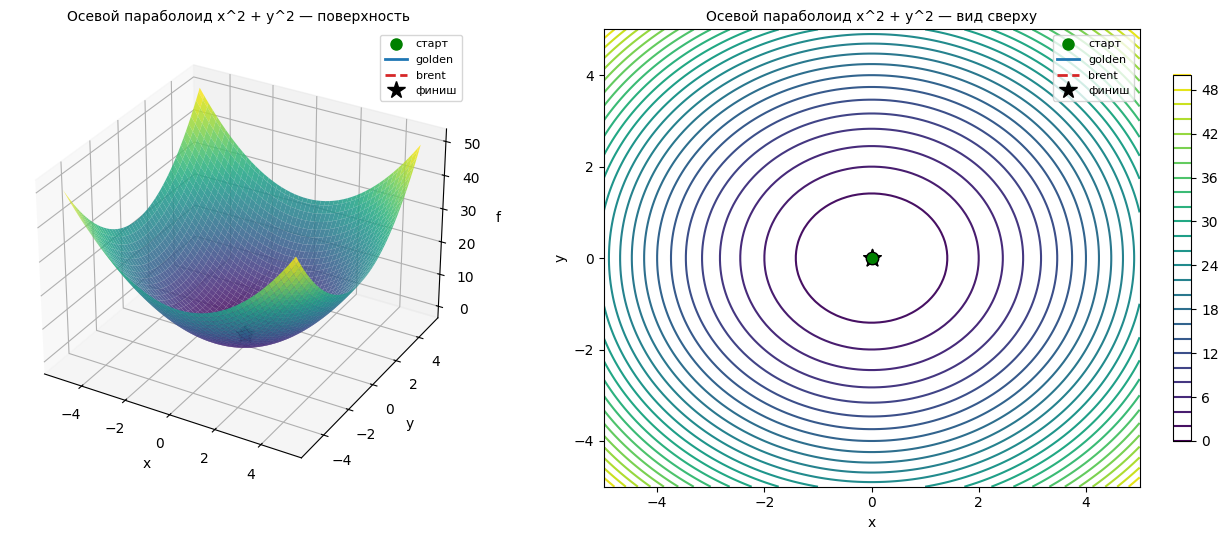

Осевой параболоид x^2 + y^2: golden = 1 итераций, brent = 1 итераций


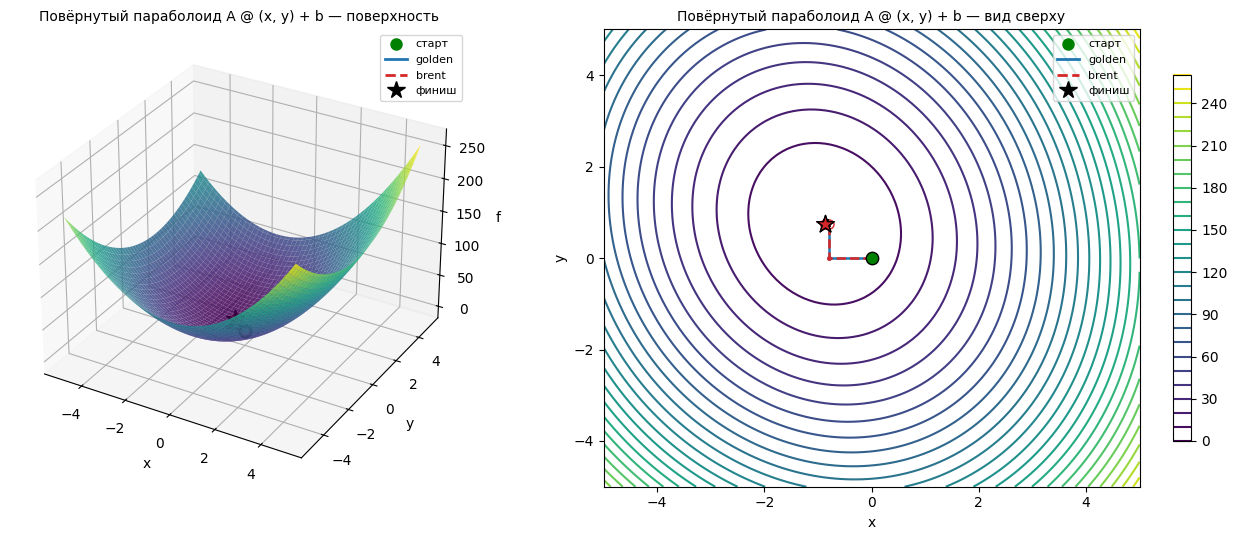

Повёрнутый параболоид A @ (x, y) + b: golden = 4 итераций, brent = 4 итераций


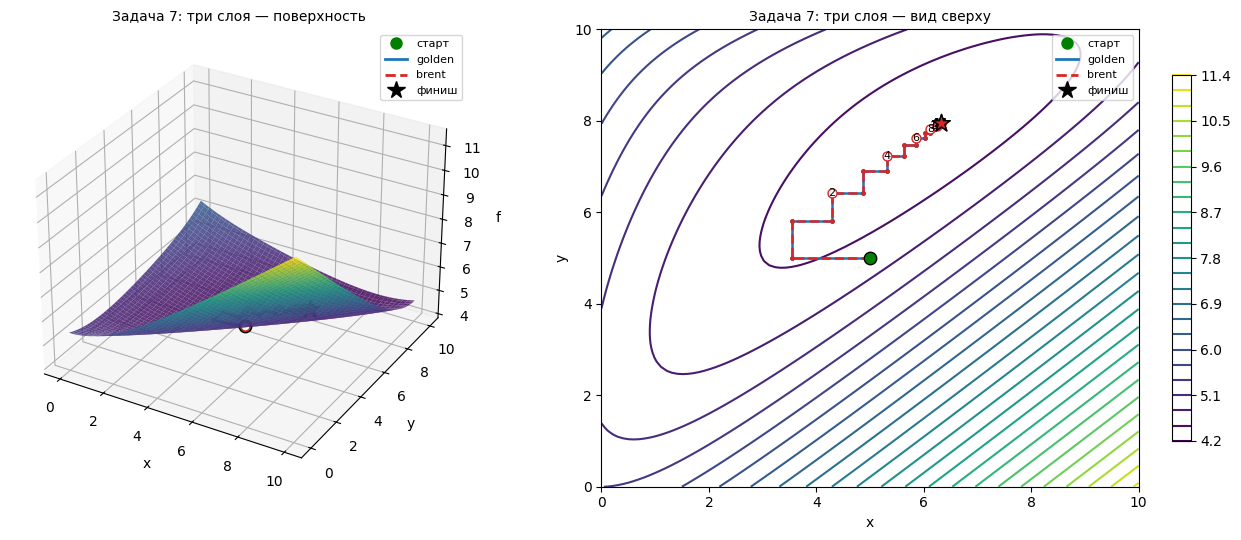

Задача 7: три слоя: golden = 19 итераций, brent = 19 итераций


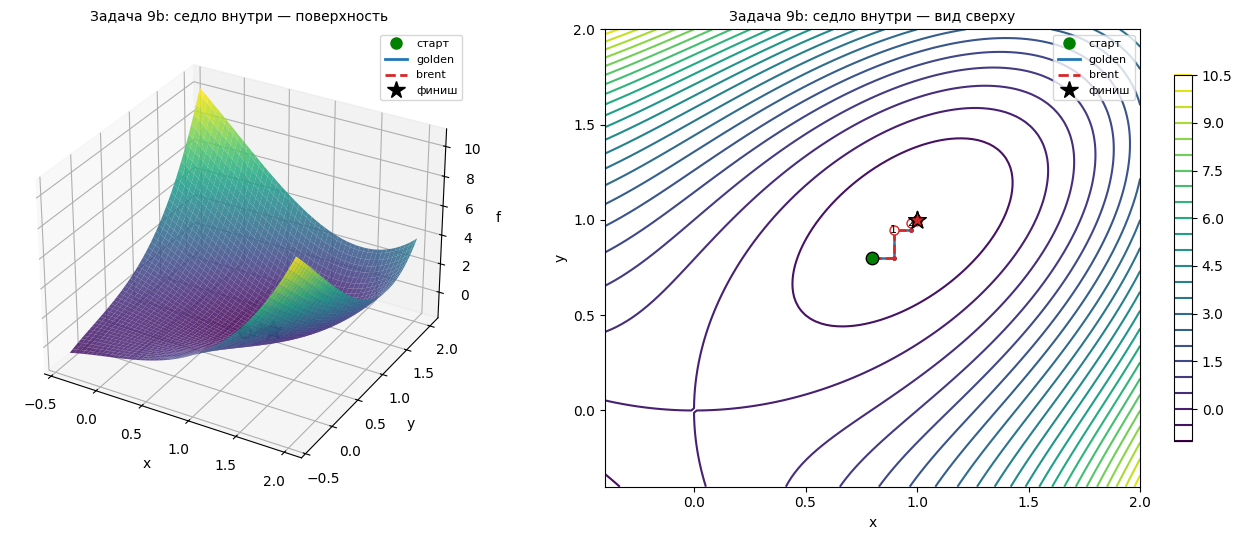

Задача 9b: седло внутри: golden = 6 итераций, brent = 6 итераций


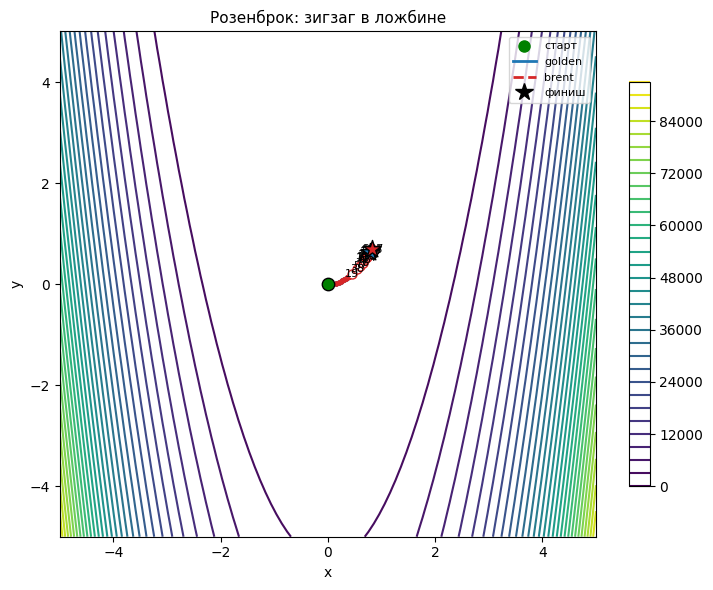

Розенброк: зигзаг в ложбине: golden = 189 итераций, brent = 247 итераций


In [10]:
GRAPHS = [
    (f_paraboloid,     R5,                          'Осевой параболоид x^2 + y^2',           5,  True),
    (f_paraboloid_rot, R5,                          'Повёрнутый параболоид A @ (x, y) + b', 10,  True),
    (f_7,              [[0.0, 10.0], [0.0, 10.0]],  'Задача 7: три слоя',                   10,  True),
    (f_9,              [[-0.4, 2.0], [-0.4, 2.0]],  'Задача 9b: седло внутри',              10,  True),
    (f_rosenbrock,     R5,                          'Розенброк: зигзаг в ложбине',          14,  False),
]

for f, bounds, title, marks, surface in GRAPHS:
    iters = show_case(f, bounds, title, n_marks=marks, surface=surface)
    print(f'{title}: golden = {iters["golden"]} итераций, brent = {iters["brent"]} итераций')


Вывод: Для проверки координатного спуска использовался набор из 16 тестов. Тесты проходили для 3-х вариантов реализации координатного спуска, т. к. эффективность работы этого метода зависит от качества одномерного шага, поэтому мы сравнивали золотое сечение, метод параболической аппроксимации и метод Брента. Спуск стартует из центра области поиска, eps = 1e-3. 

Сравнение показало, что успешно пройденных тестов для каждого метода было: golden 15/16 и brent 15/16 (все, кроме овражной функции), parabolic — 10/16. При этом Брент делает меньше вызовов целевой функции, чем реализация с золотым сечением (362 против 874 вызовов на задаче 7), что ранее уже демонстрировалось на одномерных задачах и объясняется использованием параболической аппроксимации в методе Брента. У реализации одномерного шага методом парабол 5 отказов (ValueError ×4, ZeroDivisionError ×1) и 1 «не сошлось» на овражной функции. Это показывает, что данный метод применим на узком диапазоне задач, однако эффективен как составляющий компонент метода Брента. 

Отсутствие сходимости всех вариантов реализации координатного спуска на овражной функции подтверждает теоретическое предположение о неэффективности данного метода для данной задачи. На Розенброке все методы выдали converged=True, хотя не достигли истинного минимума. Это доказывает, что флаг сходимости означает лишь, что координаты перестали меняться, а не «найден глобальный минимум». Также результат зависит от старта и области поиска (пример с температурой: старт в седле уводит в угол (-2;-2). Формально это глобальный минимум на заданной области, но с точки зрения поставленной задачи это не искомая точка.чка.